# Single-Pulse Analysis

Analyzes single-electrode stimulation results from `closed_loop_no_encoder_500msinterval_DEBUG`.
PCA is fit on visual orientation epoch vectors (same basis as `analyze_closed_loop_results.ipynb`).

In [1]:
import os
import pickle
import json
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as mcm
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from sklearn.decomposition import PCA

# ── Paths ──────────────────────────────────────────────────────────────────
DATA_DIR = "/Users/shubhom/Documents/high_dimensional_stim_sim/outputs/data_system_sim_0.05scale/no_encoder_1sinterval_sessions"
VIS_DIR  = "outputs/data_system_sim_0.05scale/visual_orientations_8"

VIZ_DIR = os.path.join(DATA_DIR, "viz")
os.makedirs(VIZ_DIR, exist_ok=True)

N_STIM_CHANNELS = 32

# Count sessions
session_dirs = sorted([d for d in os.listdir(DATA_DIR) 
                       if d.startswith("closed_loop_no_encoder_1sinterval_session_") 
                       and os.path.isdir(os.path.join(DATA_DIR, d))])
print(f"Loading {len(session_dirs)} sessions...")
for d in session_dirs:
    print(f"  - {d}")


Loading 16 sessions...
  - closed_loop_no_encoder_1sinterval_session_000
  - closed_loop_no_encoder_1sinterval_session_001
  - closed_loop_no_encoder_1sinterval_session_002
  - closed_loop_no_encoder_1sinterval_session_003
  - closed_loop_no_encoder_1sinterval_session_004
  - closed_loop_no_encoder_1sinterval_session_005
  - closed_loop_no_encoder_1sinterval_session_006
  - closed_loop_no_encoder_1sinterval_session_007
  - closed_loop_no_encoder_1sinterval_session_008
  - closed_loop_no_encoder_1sinterval_session_009
  - closed_loop_no_encoder_1sinterval_session_010
  - closed_loop_no_encoder_1sinterval_session_011
  - closed_loop_no_encoder_1sinterval_session_012
  - closed_loop_no_encoder_1sinterval_session_013
  - closed_loop_no_encoder_1sinterval_session_014
  - closed_loop_no_encoder_1sinterval_session_015


In [2]:
# ── Fit PCA on visual-orientation epoch vectors ────────────────────────────
# Same procedure as analyze_closed_loop_results.ipynb — PCA basis is shared.

with open(os.path.join(VIS_DIR, "visual8_spike_rates.pkl"), "rb") as f:
    vis_rates = pickle.load(f)
with open(os.path.join(VIS_DIR, "visual8_run_config.pkl"), "rb") as f:
    vis_config = pickle.load(f)

sample_info      = vis_config["sample_info"]
vis_centers_ms   = np.arange(vis_rates.shape[0]) * 100.0 + 250.0
orientations_deg = sorted(set(s[2] for s in sample_info))

epoch_vectors, epoch_angles = [], []
for start_ms, end_ms, angle_deg, _ in sample_info:
    mask = (vis_centers_ms >= start_ms) & (vis_centers_ms < end_ms)
    if mask.sum() == 0:
        continue
    epoch_vectors.append(vis_rates[mask].mean(axis=0))
    epoch_angles.append(angle_deg)
epoch_vectors = np.array(epoch_vectors)
epoch_angles  = np.array(epoch_angles)

avg_vectors = np.array([epoch_vectors[epoch_angles == a].mean(axis=0) for a in orientations_deg])
avg_angles  = np.array(orientations_deg)

pca = PCA(n_components=3)
pca.fit(epoch_vectors)
avg_pca   = pca.transform(avg_vectors)
epoch_pca = pca.transform(epoch_vectors)
n_pca_neurons = epoch_vectors.shape[1]
print(f"Explained variance (PC1-3): {pca.explained_variance_ratio_.round(3)}")

# Visual response mean = PCA origin (mean of the visual training distribution).
# pca.transform(pca.mean_[None, :])[0] is identically [0, 0, 0] by construction.
vis_mean_pc = np.zeros(3)

# Orientation colormap
ori_cmap   = plt.get_cmap("hsv")
ori_colors = {a: ori_cmap(i / len(orientations_deg)) for i, a in enumerate(orientations_deg)}


Explained variance (PC1-3): [0.074 0.064 0.052]


In [3]:
import pickle
import numpy as np
from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt

# Load spontaneous_baseline_noduration experiment data
data_dir = "outputs/data_system_sim_0.05scale/spontaneous_baseline_noduration/"
spont_bins_file = os.path.join(data_dir, "spontaneous_baseline_noduration_spike_bins.npz")

# Load spike bins: (n_intervals, bins_per_interval, n_neurons)
spont_data = np.load(spont_bins_file)
spont_bins = spont_data['spike_bins']
spont_bin_ms = spont_data['bin_ms']

print(f"Spontaneous data shape: {spont_bins.shape}")
print(f"Bin size: {spont_bin_ms} ms")

# Flatten bins into firing rates: (n_intervals * bins_per_interval, n_neurons)
n_spont_intervals, bins_per_interval, n_spont_neurons = spont_bins.shape
spont_bins_flat = spont_bins.reshape(-1, n_spont_neurons) / spont_bin_ms  # Convert to Hz

# Use only neurons that were in PCA training
n_pca_neurons = avg_vectors.shape[1]
spont_bins_flat = spont_bins_flat[:, :n_pca_neurons]

# Project average spontaneous activity into PC space
spont_mean_hz = spont_bins_flat.mean(axis=0)
no_stim_ever_pc = pca.transform(spont_mean_hz[None, :])[0]

print(f"Spontaneous mean firing rate shape: {spont_mean_hz.shape}")
print(f"Spontaneous mean in PC space: {no_stim_ever_pc}")

# Project each time bin into PC space for the KDE plot
spont_pc_trajectory = pca.transform(spont_bins_flat)
print(f"Spontaneous trajectory in PC space shape: {spont_pc_trajectory.shape}")

Spontaneous data shape: (200, 100, 3858)
Bin size: 5.0 ms
Spontaneous mean firing rate shape: (3858,)
Spontaneous mean in PC space: [-0.01364404 -0.00654239 -0.00023528]
Spontaneous trajectory in PC space shape: (20000, 3)


In [4]:
# ── Aggregate multi-session spike data ────────────────────────────────────
import pandas as pd


# Collect data from all sessions
all_spike_bins_list = []
all_spike_counts_list = []
all_histories = []
sessions_loaded = []

# Rich indexing structures for variable trial counts
session_map = {}            # (session_id, trial_idx, repertoire_idx) -> global_interval_idx
global_interval_idx = 0
global_trial_idx = 0
trial_structure_per_session = {}
condition_interval_map = defaultdict(list)   # (ch, amp_uA) -> [global_interval_idx, ...]
condition_trial_map = defaultdict(set)       # (ch, amp_uA) -> {(session_id, trial_idx), ...}
no_stim_interval_indices = []
no_stim_trial_keys = set()

session_dirs = sorted([d for d in os.listdir(DATA_DIR)
                       if d.startswith("closed_loop_no_encoder_1sinterval_session_")
                       and os.path.isdir(os.path.join(DATA_DIR, d))])

for session_dir in session_dirs:
    session_path = os.path.join(DATA_DIR, session_dir)
    # Extract session number from directory name (e.g., "closed_loop_no_encoder_1sinterval_session_000" -> 0)
    session_id = int(session_dir.split("_")[-1])
    print ("Session: ", session_id)
    # Load config
    config_json = os.path.join(session_path, f"closed_loop_no_encoder_session_{session_id:03d}_config.json")
    config_pkl  = os.path.join(session_path, f"closed_loop_no_encoder_session_{session_id:03d}_config.pkl")
    if os.path.isfile(config_json):
        with open(config_json) as f:
            session_config = json.load(f)
    else:
        with open(config_pkl, "rb") as f:
            session_config = pickle.load(f)

    # Load history
    history_path = os.path.join(session_path, f"closed_loop_no_encoder_session_{session_id:03d}_history.pkl")
    with open(history_path, "rb") as f:
        session_history = pickle.load(f)
    
    # Load spike data
    spike_bins_path = os.path.join(session_path, f"closed_loop_no_encoder_session_{session_id:03d}_spike_bins.npz")
    d = np.load(spike_bins_path)
    bin_ms = float(d["bin_ms"])
    session_spike_bins = d["spike_bins"].astype(np.float32)  # (n_intervals, bpi, n_neurons)

    spike_counts_path = os.path.join(session_path, f"closed_loop_no_encoder_session_{session_id:03d}_spike_counts.pkl")
    with open(spike_counts_path, "rb") as f:
        session_spike_counts = pickle.load(f)  # (n_intervals, n_neurons)

    # Track metadata
    nest_seed = session_config.get("nest_seed", None)
    sessions_loaded.append((session_id, nest_seed))

    n_intervals_session = session_spike_bins.shape[0]
    n_repertoire_session = int(session_config.get("n_repertoire", N_STIM_CHANNELS + 1))
    n_complete_trials = n_intervals_session // n_repertoire_session
    n_complete_intervals = n_complete_trials * n_repertoire_session
    n_dropped = n_intervals_session - n_complete_intervals

    if n_dropped > 0:
        print(f"Session {session_id:03d}: dropping {n_dropped} incomplete intervals")

    # Keep complete trials only, per session (avoids cross-session assumptions).
    session_spike_bins = session_spike_bins[:n_complete_intervals]
    session_spike_counts = session_spike_counts[:n_complete_intervals]
    session_history = session_history[:n_complete_intervals]

    trial_structure_per_session[session_id] = {
        "n_intervals_raw": n_intervals_session,
        "n_repertoire": n_repertoire_session,
        "n_complete_trials": n_complete_trials,
        "n_complete_intervals": n_complete_intervals,
        "n_dropped_intervals": n_dropped,
    }

    # Session-local trial indices map to a contiguous global trial index range.
    session_trial_start = global_trial_idx

    for local_interval_idx, hist_entry in enumerate(session_history):
        trial_idx = local_interval_idx // n_repertoire_session
        repertoire_idx = local_interval_idx % n_repertoire_session

        # Copy before annotation to avoid mutating data loaded from disk.
        hist_entry = dict(hist_entry)
        hist_entry["session_id"] = session_id
        hist_entry["trial_idx_in_session"] = trial_idx
        hist_entry["repertoire_idx_in_trial"] = repertoire_idx
        hist_entry["global_interval_idx"] = global_interval_idx
        hist_entry["global_trial_idx"] = session_trial_start + trial_idx

        session_map[(session_id, trial_idx, repertoire_idx)] = global_interval_idx

        pat = hist_entry.get("delivered_pattern")
        if pat is not None and len(pat.get("channels", [])) > 0:
            ch = int(pat["channels"][0])
            amp = float(pat["amplitudes_uA"][0])
            key = (ch, amp)
            condition_interval_map[key].append(global_interval_idx)
            condition_trial_map[key].add((session_id, trial_idx))
        else:
            no_stim_interval_indices.append(global_interval_idx)
            no_stim_trial_keys.add((session_id, trial_idx))

        all_histories.append(hist_entry)
        global_interval_idx += 1

    global_trial_idx += n_complete_trials

    all_spike_bins_list.append(session_spike_bins)
    all_spike_counts_list.append(session_spike_counts)

if len(all_spike_bins_list) == 0:
    raise RuntimeError(f"No sessions found in DATA_DIR: {DATA_DIR}")

# Concatenate all spike data along interval axis
spike_bins_arr = np.concatenate(all_spike_bins_list, axis=0)  # (total_intervals, bpi, n_neurons)
spike_counts_matrix = np.concatenate(all_spike_counts_list, axis=0)  # (total_intervals, n_neurons)

# Get dimensions after per-session complete-trial filtering
n_intervals, bpi, n_neurons_raw = spike_bins_arr.shape
n_sessions = len(sessions_loaded)
total_trials = sum(v["n_complete_trials"] for v in trial_structure_per_session.values())

trials_per_session_values = [v["n_complete_trials"] for v in trial_structure_per_session.values()]
n_repertoire_values = [v["n_repertoire"] for v in trial_structure_per_session.values()]
trials_per_session = trials_per_session_values[0] if len(set(trials_per_session_values)) == 1 else None
n_repertoire = n_repertoire_values[0] if len(set(n_repertoire_values)) == 1 else None

# Config aggregation: preserve per-session structure
config = {
    "n_sessions": n_sessions,
    "sessions_loaded": sessions_loaded,
    "total_intervals": n_intervals,
    "total_trials": total_trials,
    "trials_per_session": trials_per_session,
    "trials_per_session_by_session": {sid: info["n_complete_trials"] for sid, info in trial_structure_per_session.items()},
    "n_repertoire": n_repertoire,
    "n_repertoire_by_session": {sid: info["n_repertoire"] for sid, info in trial_structure_per_session.items()},
    "bin_ms": bin_ms,
}

# History is the concatenated and annotated list
history = all_histories

# Mean firing rate (Hz) over each full interval: (n_intervals, n_neurons)
interval_hz = spike_bins_arr[:, :, :n_pca_neurons].mean(axis=1) / bin_ms

# Project all intervals into PC space
all_pc = pca.transform(interval_hz)  # (n_intervals, 3)

# Spontaneous activity baseline: no stimulation is delivered in no-stim slots
no_stim_idx = no_stim_interval_indices
if len(no_stim_idx) == 0:
    raise RuntimeError("No no-stim intervals found after filtering.")
spont_hz = spike_bins_arr[no_stim_idx, :, :n_pca_neurons].mean(axis=(0, 1)) / bin_ms
spont_trials_pc = pca.transform(spont_hz[None, :])[0]

# Condition-level counts (supports non-uniform trial counts by condition).
condition_interval_counts = {k: len(v) for k, v in condition_interval_map.items()}
condition_trial_counts = {k: len(v) for k, v in condition_trial_map.items()}

print(f"\n=== MULTI-SESSION AGGREGATION SUMMARY ===")
print(f"Sessions loaded: {n_sessions}")
print(f"  Session IDs: {[s[0] for s in sessions_loaded]}")
print(f"Total intervals (complete only): {n_intervals}")
if trials_per_session is None:
    print(f"Trials per session vary: min={min(trials_per_session_values)} max={max(trials_per_session_values)}")
else:
    print(f"Trials per session: {trials_per_session}")
print(f"Total trials: {total_trials}")
if n_repertoire is None:
    print(f"Repertoire size varies by session: {sorted(set(n_repertoire_values))}")
else:
    print(f"Repertoire size (n_repertoire): {n_repertoire}")
print(f"Bin resolution: {bin_ms} ms")
print(f"PCA neurons: {n_pca_neurons}")

print(f"\nSpike data shapes:")
print(f"  spike_bins_arr: {spike_bins_arr.shape}  (total_intervals × bins_per_interval × neurons)")
print(f"  spike_counts_matrix: {spike_counts_matrix.shape}  (total_intervals × neurons)")

print(f"\nProjection to PC space:")
print(f"  all_pc shape: {all_pc.shape}  (total_intervals × 3)")

if len(condition_trial_counts) > 0:
    trial_count_values = list(condition_trial_counts.values())
    print(f"\nCondition trial counts (channel × amplitude):")
    print(f"  conditions with stim: {len(condition_trial_counts)}")
    print(f"  min/median/max trials per condition: {min(trial_count_values)} / {int(np.median(trial_count_values))} / {max(trial_count_values)}")

print(f"\nSpontaneous baseline (no-stim):")
print(f"  Averaged over {len(no_stim_idx)} no-stim intervals")
print(f"  Unique no-stim trials: {len(no_stim_trial_keys)}")
print(f"  spont_trials_pc = {spont_trials_pc.round(4)}")


Session:  0
Session 000: dropping 34 incomplete intervals
Session:  1
Session 001: dropping 34 incomplete intervals
Session:  2
Session 002: dropping 34 incomplete intervals
Session:  3
Session 003: dropping 24 incomplete intervals
Session:  4
Session 004: dropping 34 incomplete intervals
Session:  5
Session 005: dropping 34 incomplete intervals
Session:  6
Session 006: dropping 34 incomplete intervals
Session:  7
Session 007: dropping 34 incomplete intervals
Session:  8
Session 008: dropping 24 incomplete intervals
Session:  9
Session 009: dropping 34 incomplete intervals
Session:  10
Session 010: dropping 34 incomplete intervals
Session:  11
Session 011: dropping 34 incomplete intervals
Session:  12
Session 012: dropping 34 incomplete intervals
Session:  13
Session 013: dropping 24 incomplete intervals
Session:  14
Session 014: dropping 34 incomplete intervals
Session:  15
Session 015: dropping 34 incomplete intervals

=== MULTI-SESSION AGGREGATION SUMMARY ===
Sessions loaded: 16
  S

In [5]:
import pandas as pd

trials_df = pd.DataFrame(history)
print(f"\nHistory DataFrame shape: {trials_df.shape}")
print(f"History columns: {trials_df.columns.tolist()}")
coverage = (trials_df.groupby("session_id").aggregate({"trial_idx_in_session": "max", "repertoire_idx_in_trial": "max"}))
coverage["trial_idx_in_session"] += 1  # Convert max index to count
coverage["repertoire_idx_in_trial"] += 1   
coverage


History DataFrame shape: (6176, 11)
History columns: ['interval_index', 'interval_start_ms', 'interval_end_ms', 'n_new_spikes', 'actual_l2', 'delivered_pattern', 'session_id', 'trial_idx_in_session', 'repertoire_idx_in_trial', 'global_interval_idx', 'global_trial_idx']


,trial_idx_in_session,repertoire_idx_in_trial
session_id,,
0,2,193
1,2,193
2,2,193
3,2,193
4,2,193
5,2,193
6,2,193
7,2,193
8,2,193


In [6]:
# ── Collect pre→post shift vectors per electrode ───────────────────────────
#
# For interval i with a delivered pattern:
#   pre  = PC projection of interval i-1
#   post = PC projection of interval i
#   shift = post - pre

shifts_by_ch   = defaultdict(list)   # ch -> list of (pre_pc, post_pc)
shifts_no_stim = []                  # no-stim intervals

for i, h in enumerate(history):
    if i == 0:
        continue
    pat     = h.get("delivered_pattern")
    pre_pc  = all_pc[i - 1]
    post_pc = all_pc[i]
    if pat is not None and len(pat.get("channels", [])) > 0:
        ch = int(pat["channels"][0])
        shifts_by_ch[ch].append((pre_pc, post_pc))
    else:
        shifts_no_stim.append((pre_pc, post_pc))

print(f"Electrodes with data: {sorted(shifts_by_ch.keys())}")
print(f"No-stim intervals: {len(shifts_no_stim)}")
print(f"Stim intervals: {sum(len(v) for v in shifts_by_ch.values())}")

Electrodes with data: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31]
No-stim intervals: 31
Stim intervals: 6144


In [7]:
# ── Shift magnitude per electrode ──────────────────────────────────────────

print("Mean shift magnitude (PC1-2 norm) per electrode:")
mags = {}
for ch, pairs in sorted(shifts_by_ch.items()):
    diffs = np.array([post[:2] - pre[:2] for pre, post in pairs])
    mags[ch] = diffs.mean(axis=0)
    print(f"  ch{ch:02d}: |shift|={np.linalg.norm(mags[ch]):.4f}  (n={len(pairs)})")

if shifts_no_stim:
    ns_diffs = np.array([post[:2] - pre[:2] for pre, post in shifts_no_stim])
    ns_mag   = np.linalg.norm(ns_diffs.mean(axis=0))
    print(f"  no-stim: |shift|={ns_mag:.4f}  (n={len(shifts_no_stim)})")

Mean shift magnitude (PC1-2 norm) per electrode:
  ch00: |shift|=0.0006  (n=192)
  ch01: |shift|=0.0008  (n=192)
  ch02: |shift|=0.0002  (n=192)
  ch03: |shift|=0.0001  (n=192)
  ch04: |shift|=0.0002  (n=192)
  ch05: |shift|=0.0002  (n=192)
  ch06: |shift|=0.0001  (n=192)
  ch07: |shift|=0.0003  (n=192)
  ch08: |shift|=0.0002  (n=192)
  ch09: |shift|=0.0001  (n=192)
  ch10: |shift|=0.0003  (n=192)
  ch11: |shift|=0.0003  (n=192)
  ch12: |shift|=0.0000  (n=192)
  ch13: |shift|=0.0001  (n=192)
  ch14: |shift|=0.0003  (n=192)
  ch15: |shift|=0.0002  (n=192)
  ch16: |shift|=0.0003  (n=192)
  ch17: |shift|=0.0005  (n=192)
  ch18: |shift|=0.0003  (n=192)
  ch19: |shift|=0.0002  (n=192)
  ch20: |shift|=0.0003  (n=192)
  ch21: |shift|=0.0003  (n=192)
  ch22: |shift|=0.0002  (n=192)
  ch23: |shift|=0.0004  (n=192)
  ch24: |shift|=0.0002  (n=192)
  ch25: |shift|=0.0003  (n=192)
  ch26: |shift|=0.0003  (n=192)
  ch27: |shift|=0.0003  (n=192)
  ch28: |shift|=0.0002  (n=192)
  ch29: |shift|=0.0002 

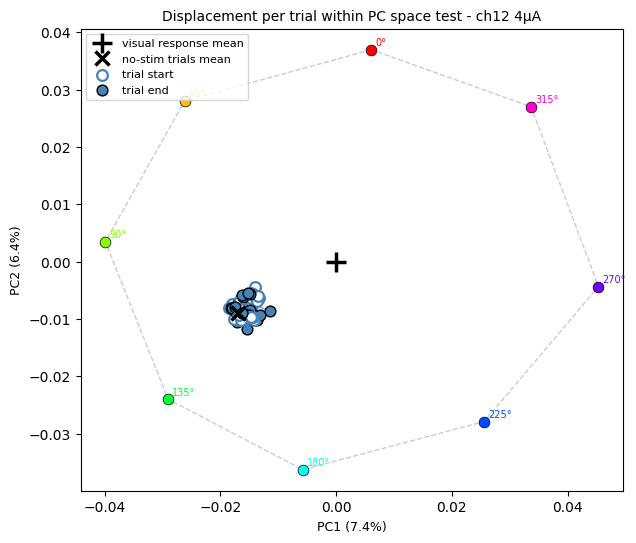

Saved -> /Users/shubhom/Documents/high_dimensional_stim_sim/outputs/data_system_sim_0.05scale/no_encoder_1sinterval_sessions/viz/trial_start_end_vectors.png


In [ ]:
# ── Per-trial start→end vectors in PC space ───────────────────────────────
# Each trial is shown as a straight line from its first to its last interval.
# All trials overlay in the same color.
#
# TRIALS_TO_PLOT: list of trial indices, or None to show all trials.

TEST_CURRENT = 4
TEST_ELECTRODE = 12
trials = []
for t in range(len(history)):
    pat = history[t]["delivered_pattern"]
    if pat is not None:
        ch = pat["channels"][0]
        amp = pat["amplitudes_uA"][0]
        if ch == TEST_ELECTRODE and amp == TEST_CURRENT:
            trials.append(t)
if len(trials) == 0:
    trials = None


fig, ax = plt.subplots(figsize=(7, 6))

# Orientation ring
ring_ord = np.argsort(avg_angles)
ax.plot(
    np.append(avg_pca[ring_ord, 0], avg_pca[ring_ord[0], 0]),
    np.append(avg_pca[ring_ord, 1], avg_pca[ring_ord[0], 1]),
    "--", color="grey", lw=1.0, alpha=0.4,
)
for j, ang in enumerate(avg_angles):
    ax.scatter(avg_pca[j, 0], avg_pca[j, 1],
               color=ori_colors[ang], s=60, edgecolors="k", lw=0.5, zorder=3)
    ax.annotate(f"{int(ang)}°",
                xy=(avg_pca[j, 0], avg_pca[j, 1]),
                xytext=(3, 3), textcoords="offset points",
                fontsize=7, color=ori_colors[ang])

# Reference markers
ax.plot(vis_mean_pc[0], vis_mean_pc[1],
        marker="+", markersize=14, 
        color="black", linestyle="none", zorder=10,
        label="visual response mean")
ax.plot(spont_trials_pc[0], spont_trials_pc[1],
        marker="x", markersize=10, 
        color="black", linestyle="none", zorder=10,
        label="no-stim trials mean")

# One line per trial: start (open circle) → end (filled circle)
for t in trials:
    p_start = all_pc[t] # TODO: replace with instant spike PC projection at trial start vs. trial end. 
    p_end   = all_pc[t - 1]
    ax.plot([p_start[0], p_end[0]], [p_start[1], p_end[1]],
            color="steelblue", lw=1.2, alpha=0.6, zorder=5)
    label_s = "trial start" if t == trials[0] else None
    label_e = "trial end"   if t == trials[0] else None
    ax.scatter(p_start[0], p_start[1], color="white", s=60,
               edgecolors="steelblue", lw=1.6, zorder=7, label=label_s)
    ax.scatter(p_end[0],   p_end[1],   color="steelblue", s=60,
               edgecolors="k", lw=1.0, zorder=7, label=label_e)

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})", fontsize=9)
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})", fontsize=9)
ax.set_title(
    f"Displacement per trial within PC space test - ch{TEST_ELECTRODE} {TEST_CURRENT}µA", 
    fontsize=10,
)
ax.legend(fontsize=8, loc="upper left")

out = os.path.join(VIZ_DIR, "trial_start_end_vectors.png")
plt.savefig(out, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved -> {out}")

bin_ms=5.0  offset_bins=1  obs_bins=4
Window: t=[5 … 25] ms post-stim onset

Electrodes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31]
Amplitudes: [1.0, 2.0, 3.0, 4.0, 5.0, 6.0] uA
N_e=32  N_a=6  observed (ch,amp) pairs=192
Trials per (ch,amp): min/median/max = 32 / 32 / 32
Intervals per (ch,amp): min/median/max = 32 / 32 / 32


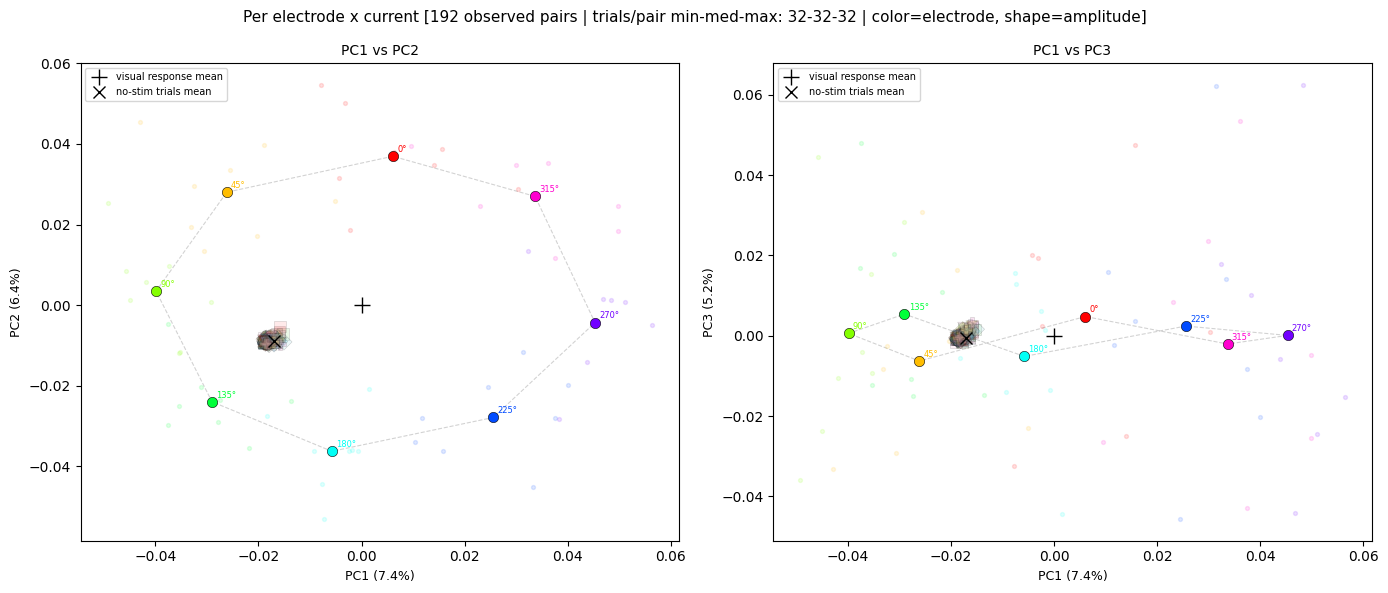

Saved -> /Users/shubhom/Documents/high_dimensional_stim_sim/outputs/data_system_sim_0.05scale/no_encoder_1sinterval_sessions/viz/single_pulse_obs_window_ch_amp.png


In [23]:
# ── Observation-window averages projected into PC space ─────────────────────
#
# Mirrors explore_sta.ipynb:
#   OBS_WINDOW_MS — duration of post-stim window to average (ms)
#   OFFSET_MS     — start of window relative to stim onset (ms); skip artifact
#
# PLOT_MODE controls what gets plotted (one panel, 2 PC projections):
#   "ch_amp"    — one point per (electrode × amplitude): N_e × N_a points
#                 color = electrode, shape = amplitude
#   "electrode" — one point per electrode (marginalised over amplitude): N_e points
#                 color = electrode, single marker shape
#   "current"   — one point per amplitude (marginalised over electrode): N_a points
#                 color = amplitude, single marker shape

PLOT_MODE     = "ch_amp"   # "ch_amp" | "electrode" | "current"
OBS_WINDOW_MS = 20.0       # ms of post-stim window to average
OFFSET_MS     = 5.0        # ms after stim onset before window starts

offset_bins = int(OFFSET_MS     / bin_ms)
obs_bins    = int(OBS_WINDOW_MS / bin_ms)
print(f"bin_ms={bin_ms}  offset_bins={offset_bins}  obs_bins={obs_bins}")
print(f"Window: t=[{OFFSET_MS:.0f} … {OFFSET_MS + OBS_WINDOW_MS:.0f}] ms post-stim onset")

# ── Collect per-(ch, amp) vectors with explicit trial membership ────────────
obs_by_condition = defaultdict(lambda: {
    "obs_hz": [],            # interval-level vectors, one per stim interval
    "interval_indices": [],  # global interval indices
    "trial_keys": set(),     # {(session_id, trial_idx_in_session), ...}
})

for i, h in enumerate(history):
    pat = h.get("delivered_pattern")
    if pat is None or len(pat.get("channels", [])) == 0:
        continue

    win = spike_bins_arr[i, offset_bins : offset_bins + obs_bins, :n_pca_neurons]
    if win.shape[0] < obs_bins:
        continue   # window shorter than requested — skip

    obs_hz = win.mean(axis=0) / bin_ms   # (n_pca_neurons,) Hz
    ch  = int(pat["channels"][0])
    amp = float(pat["amplitudes_uA"][0])
    key = (ch, amp)

    obs_by_condition[key]["obs_hz"].append(obs_hz)
    obs_by_condition[key]["interval_indices"].append(i)
    obs_by_condition[key]["trial_keys"].add((h["session_id"], h["trial_idx_in_session"]))

if len(obs_by_condition) == 0:
    raise RuntimeError("No stimulated intervals found for the requested observation window.")

all_amps = sorted(set(amp for ch, amp in obs_by_condition))
all_chs  = sorted(set(ch  for ch, amp in obs_by_condition))
N_e, N_a = len(all_chs), len(all_amps)

# Per-condition counts (no equal-trial assumption).
trial_counts_per_pair = {key: len(val["trial_keys"]) for key, val in obs_by_condition.items()}
interval_counts_per_pair = {key: len(val["obs_hz"]) for key, val in obs_by_condition.items()}

trial_count_values = list(trial_counts_per_pair.values())
interval_count_values = list(interval_counts_per_pair.values())

print(f"\nElectrodes: {all_chs}")
print(f"Amplitudes: {all_amps} uA")
print(f"N_e={N_e}  N_a={N_a}  observed (ch,amp) pairs={len(obs_by_condition)}")
print(f"Trials per (ch,amp): min/median/max = {min(trial_count_values)} / {int(np.median(trial_count_values))} / {max(trial_count_values)}")
print(f"Intervals per (ch,amp): min/median/max = {min(interval_count_values)} / {int(np.median(interval_count_values))} / {max(interval_count_values)}")

# ── Compute PC coords for each grouping ───────────────────────────────────
avg_ch_amp_pc = {}   # (ch, amp) -> (3,)
for key, val in obs_by_condition.items():
    avg_ch_amp_pc[key] = pca.transform(np.stack(val["obs_hz"]).mean(axis=0)[None])[0]

avg_electrode_pc = {}   # ch -> (3,)
trial_counts_by_electrode = {}
for ch in all_chs:
    vecs = [v for (c, a), val in obs_by_condition.items() if c == ch for v in val["obs_hz"]]
    trial_keys = set()
    for (c, a), val in obs_by_condition.items():
        if c == ch:
            trial_keys.update(val["trial_keys"])
    avg_electrode_pc[ch] = pca.transform(np.stack(vecs).mean(axis=0)[None])[0]
    trial_counts_by_electrode[ch] = len(trial_keys)

avg_current_pc = {}   # amp -> (3,)
trial_counts_by_current = {}
for amp in all_amps:
    vecs = [v for (c, a), val in obs_by_condition.items() if a == amp for v in val["obs_hz"]]
    trial_keys = set()
    for (c, a), val in obs_by_condition.items():
        if a == amp:
            trial_keys.update(val["trial_keys"])
    avg_current_pc[amp] = pca.transform(np.stack(vecs).mean(axis=0)[None])[0]
    trial_counts_by_current[amp] = len(trial_keys)

# ── Marker shapes for amplitude ────────────────────────────────────────────
_MARKER_POOL = ["o", "s", "^", "D", "v", "P", "X", "h", "*", "p"]
amp_markers  = {amp: _MARKER_POOL[i % len(_MARKER_POOL)] for i, amp in enumerate(all_amps)}

# Amplitude colormap (used in "current" mode)
AMP_CMAP = plt.cm.viridis
amp_norm = plt.Normalize(vmin=min(all_amps),
                         vmax=max(all_amps) if N_a > 1 else max(all_amps) + 1)
amp_col  = {amp: AMP_CMAP(amp_norm(amp)) for amp in all_amps}

# ── Helper: draw orientation ring + reference markers ─────────────────────
def _draw_bg(ax, pc_x, pc_y):
    ring_ord = np.argsort(avg_angles)
    ax.plot(
        np.append(avg_pca[ring_ord, pc_x], avg_pca[ring_ord[0], pc_x]),
        np.append(avg_pca[ring_ord, pc_y], avg_pca[ring_ord[0], pc_y]),
        "--", color="grey", lw=0.8, alpha=0.35, zorder=1,
    )
    for ang in sorted(set(avg_angles.tolist())):
        m = epoch_angles == ang
        ax.scatter(epoch_pca[m, pc_x], epoch_pca[m, pc_y],
                   color=ori_colors[ang], s=8, alpha=0.12, zorder=2)
    for j, ang in enumerate(avg_angles):
        ax.scatter(avg_pca[j, pc_x], avg_pca[j, pc_y],
                   color=ori_colors[ang], s=55, edgecolors="k", lw=0.4, zorder=3)
        ax.annotate(f"{int(ang)}°",
                    xy=(avg_pca[j, pc_x], avg_pca[j, pc_y]),
                    xytext=(3, 3), textcoords="offset points",
                    fontsize=6, color=ori_colors[ang])
    ax.plot(vis_mean_pc[pc_x], vis_mean_pc[pc_y],
            "+", ms=12, color="black", zorder=9, label="visual response mean")
    ax.plot(spont_trials_pc[pc_x], spont_trials_pc[pc_y],
            "x", ms=9,  color="black", zorder=9, label="no-stim trials mean")

# ── Title ─────────────────────────────────────────────────────────────────
if PLOT_MODE == "ch_amp":
    mode_title = (
        f"Per electrode x current "
        f"[{len(obs_by_condition)} observed pairs | trials/pair min-med-max: "
        f"{min(trial_count_values)}-{int(np.median(trial_count_values))}-{max(trial_count_values)} | "
        f"color=electrode, shape=amplitude]"
    )
elif PLOT_MODE == "electrode":
    e_counts = list(trial_counts_by_electrode.values())
    mode_title = (
        f"Per electrode (marginalised over amplitude) "
        f"[{N_e} pts | trial-count/electrode min-med-max: "
        f"{min(e_counts)}-{int(np.median(e_counts))}-{max(e_counts)} | color=electrode]"
    )
elif PLOT_MODE == "current":
    c_counts = list(trial_counts_by_current.values())
    mode_title = (
        f"Per current (marginalised over electrode) "
        f"[{N_a} pts | trial-count/current min-med-max: "
        f"{min(c_counts)}-{int(np.median(c_counts))}-{max(c_counts)} | color=amplitude]"
    )
else:
    raise ValueError(f"PLOT_MODE must be 'ch_amp', 'electrode', or 'current'; got {PLOT_MODE!r}")

# ── Figure: 1 row x 2 cols ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(
    f"{mode_title}",
    fontsize=11,
)

ch_colors = {ch: plt.cm.tab20(i % 20) for i, ch in enumerate(all_chs)}

for ax, (pc_x, pc_y) in zip(axes, [(0, 1), (0, 2)]):
    _draw_bg(ax, pc_x, pc_y)

    if PLOT_MODE == "ch_amp":
        for amp in all_amps:
            xs = [avg_ch_amp_pc[(ch, amp)][pc_x] for ch in all_chs if (ch, amp) in avg_ch_amp_pc]
            ys = [avg_ch_amp_pc[(ch, amp)][pc_y] for ch in all_chs if (ch, amp) in avg_ch_amp_pc]
            cs = [ch_colors[ch]                   for ch in all_chs if (ch, amp) in avg_ch_amp_pc]
            ax.scatter(xs, ys, c=cs, s=70, marker=amp_markers[amp],
                       edgecolors="k", lw=0.4, alpha=0.2, zorder=5)

    elif PLOT_MODE == "electrode":
        xs = [avg_electrode_pc[ch][pc_x] for ch in all_chs]
        ys = [avg_electrode_pc[ch][pc_y] for ch in all_chs]
        cs = [ch_colors[ch]              for ch in all_chs]
        ax.scatter(xs, ys, c=cs, s=80, marker="o",
                   edgecolors="k", lw=0.5, alpha=0.4, zorder=5)
        for ch in all_chs:
            pc = avg_electrode_pc[ch]
            ax.annotate(str(ch), xy=(pc[pc_x], pc[pc_y]),
                        xytext=(2, 2), textcoords="offset points", fontsize=6)

    elif PLOT_MODE == "current":
        for amp in all_amps:
            pc = avg_current_pc[amp]
            ax.scatter(pc[pc_x], pc[pc_y],
                       color=amp_col[amp], s=160, marker="D",
                       edgecolors="k", lw=0.7, zorder=5)
            ax.annotate(f"{amp} uA", xy=(pc[pc_x], pc[pc_y]),
                        xytext=(5, 3), textcoords="offset points",
                        fontsize=8, fontweight="bold")

    ax.set_xlabel(f"PC{pc_x+1} ({pca.explained_variance_ratio_[pc_x]:.1%})", fontsize=9)
    ax.set_ylabel(f"PC{pc_y+1} ({pca.explained_variance_ratio_[pc_y]:.1%})", fontsize=9)
    ax.set_title(f"PC{pc_x+1} vs PC{pc_y+1}", fontsize=10)
    # ax.set_xlim(-0.025, 0.01)
    # ax.set_ylim(-0.025, 0.01)
    ax.legend(fontsize=7, loc="upper left")
plt.tight_layout()
out = os.path.join(VIZ_DIR, f"single_pulse_obs_window_{PLOT_MODE}.png")
plt.savefig(out, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved -> {out}")


In [ ]:
for current in all_amps:
    print(f"Current {current} uA:")
    for ch in all_chs:
        key = (ch, current)
        if key in avg_ch_amp_pc:
            # already have mean PC coords for this (ch, amp) pair
            pc = avg_ch_amp_pc[key]
            print(f"  Electrode {ch}: mean PC coords = {pc.round(4)}")
        
            # calculate variance across intervals for this (ch, amp) pair
            obs_hz_list = obs_by_condition[key]["obs_hz"]
            if len(obs_hz_list) > 1:
                obs_hz_array = np.stack(obs_hz_list)  # shape: (n_intervals, n_pca_neurons)
                obs_pc_array = pca.transform(obs_hz_array)  # shape: (n_intervals, 3)
                pc_variance = obs_pc_array.var(axis=0)  # variance along each PC dimension
                print(f"    Variance across intervals: {pc_variance.round(6)}")
            else:
                print(f"    Only one interval for this (ch, amp) pair; cannot compute variance.")
        else:
            print(f"  Electrode {ch}: no data for this current level.")



Current 1.0 uA:
  Electrode 0: mean PC coords = [-0.0187 -0.009  -0.0003]
    Variance across intervals: [1.e-06 3.e-06 2.e-06]
  Electrode 1: mean PC coords = [-0.0191 -0.0092 -0.0006]
    Variance across intervals: [1.e-06 2.e-06 1.e-06]
  Electrode 2: mean PC coords = [-0.0188 -0.0092 -0.0004]
    Variance across intervals: [1.e-06 1.e-06 1.e-06]
  Electrode 3: mean PC coords = [-0.0186 -0.0092 -0.001 ]
    Variance across intervals: [1.e-06 1.e-06 2.e-06]
  Electrode 4: mean PC coords = [-0.0188 -0.0094 -0.0008]
    Variance across intervals: [2.e-06 1.e-06 1.e-06]
  Electrode 5: mean PC coords = [-0.019  -0.0096 -0.0006]
    Variance across intervals: [0.e+00 0.e+00 1.e-06]
  Electrode 6: mean PC coords = [-0.0186 -0.009  -0.0009]
    Variance across intervals: [1.e-06 1.e-06 2.e-06]
  Electrode 7: mean PC coords = [-0.0187 -0.0093 -0.0005]
    Variance across intervals: [2.e-06 0.e+00 1.e-06]
  Electrode 8: mean PC coords = [-0.0189 -0.0093 -0.0009]
    Variance across intervals:

bin_ms=5.0  offset_bins=1  obs_bins=4
Window: t=[5 … 25] ms post-stim onset

Electrodes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31]
Amplitudes: [1.0, 2.0, 3.0, 4.0, 5.0, 6.0] uA
N_e=32  N_a=6  observed (ch,amp) pairs=192
Trials per (ch,amp): min/median/max = 32 / 32 / 32
Intervals per (ch,amp): min/median/max = 32 / 32 / 32


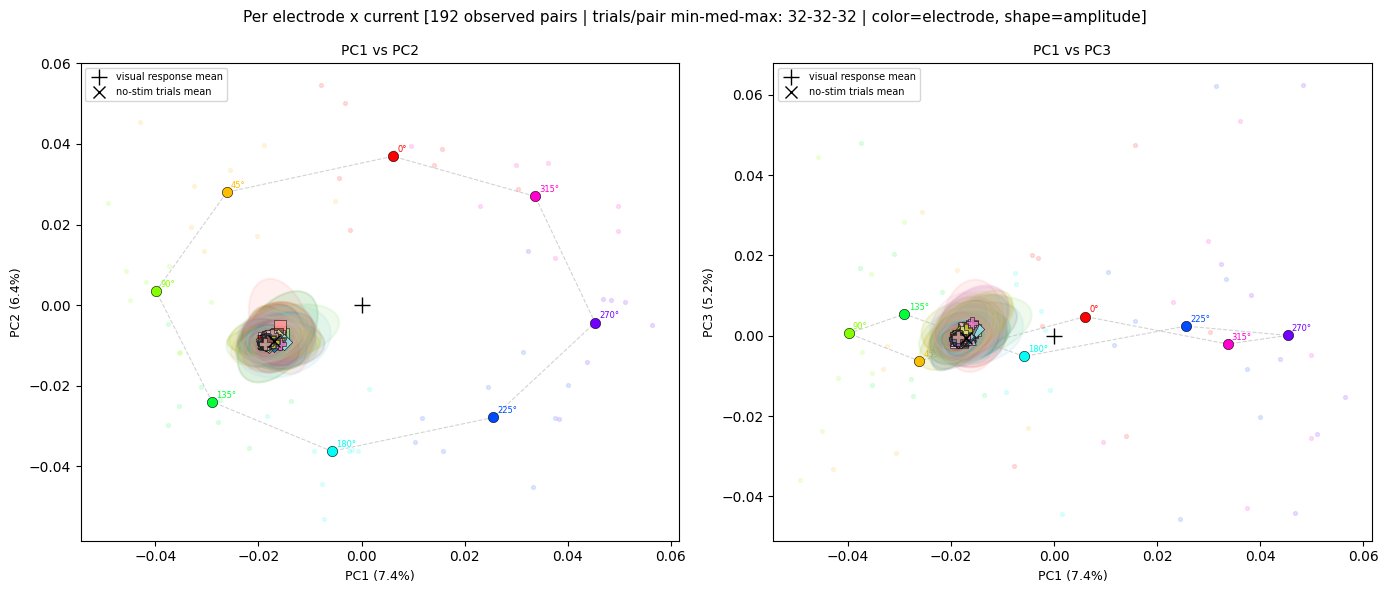

Saved -> /Users/shubhom/Documents/high_dimensional_stim_sim/outputs/data_system_sim_0.05scale/no_encoder_1sinterval_sessions/viz/single_pulse_obs_window_ch_amp.png


In [29]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from collections import defaultdict

# ── Observation-window averages projected into PC space ─────────────────────
#
# Mirrors explore_sta.ipynb:
#   OBS_WINDOW_MS — duration of post-stim window to average (ms)
#   OFFSET_MS     — start of window relative to stim onset (ms); skip artifact
#
# PLOT_MODE controls what gets plotted (one panel, 2 PC projections):
#   "ch_amp"    — one point per (electrode × amplitude): N_e × N_a points
#                 color = electrode, shape = amplitude
#   "electrode" — one point per electrode (marginalised over amplitude): N_e points
#                 color = electrode, single marker shape
#   "current"   — one point per amplitude (marginalised over electrode): N_a points
#                 color = amplitude, single marker shape

PLOT_MODE     = "ch_amp"   # "ch_amp" | "electrode" | "current"
OBS_WINDOW_MS = 20.0       # ms of post-stim window to average
OFFSET_MS     = 5.0        # ms after stim onset before window starts

offset_bins = int(OFFSET_MS     / bin_ms)
obs_bins    = int(OBS_WINDOW_MS / bin_ms)
print(f"bin_ms={bin_ms}  offset_bins={offset_bins}  obs_bins={obs_bins}")
print(f"Window: t=[{OFFSET_MS:.0f} … {OFFSET_MS + OBS_WINDOW_MS:.0f}] ms post-stim onset")

# ── Collect per-(ch, amp) vectors with explicit trial membership ────────────
obs_by_condition = defaultdict(lambda: {
    "obs_hz": [],            # interval-level vectors, one per stim interval
    "interval_indices": [],  # global interval indices
    "trial_keys": set(),     # {(session_id, trial_idx_in_session), ...}
})

for i, h in enumerate(history):
    pat = h.get("delivered_pattern")
    if pat is None or len(pat.get("channels", [])) == 0:
        continue

    win = spike_bins_arr[i, offset_bins : offset_bins + obs_bins, :n_pca_neurons]
    if win.shape[0] < obs_bins:
        continue   # window shorter than requested — skip

    obs_hz = win.mean(axis=0) / bin_ms   # (n_pca_neurons,) Hz
    ch  = int(pat["channels"][0])
    amp = float(pat["amplitudes_uA"][0])
    key = (ch, amp)

    obs_by_condition[key]["obs_hz"].append(obs_hz)
    obs_by_condition[key]["interval_indices"].append(i)
    obs_by_condition[key]["trial_keys"].add((h["session_id"], h["trial_idx_in_session"]))

if len(obs_by_condition) == 0:
    raise RuntimeError("No stimulated intervals found for the requested observation window.")

all_amps = sorted(set(amp for ch, amp in obs_by_condition))
all_chs  = sorted(set(ch  for ch, amp in obs_by_condition))
N_e, N_a = len(all_chs), len(all_amps)

# Per-condition counts (no equal-trial assumption).
trial_counts_per_pair = {key: len(val["trial_keys"]) for key, val in obs_by_condition.items()}
interval_counts_per_pair = {key: len(val["obs_hz"]) for key, val in obs_by_condition.items()}

trial_count_values = list(trial_counts_per_pair.values())
interval_count_values = list(interval_counts_per_pair.values())

print(f"\nElectrodes: {all_chs}")
print(f"Amplitudes: {all_amps} uA")
print(f"N_e={N_e}  N_a={N_a}  observed (ch,amp) pairs={len(obs_by_condition)}")
print(f"Trials per (ch,amp): min/median/max = {min(trial_count_values)} / {int(np.median(trial_count_values))} / {max(trial_count_values)}")
print(f"Intervals per (ch,amp): min/median/max = {min(interval_count_values)} / {int(np.median(interval_count_values))} / {max(interval_count_values)}")

# ── Compute PC coords & Covariance for each grouping ──────────────────────
avg_ch_amp_pc = {}   # (ch, amp) -> (3,)
cov_ch_amp_pc = {}   # (ch, amp) -> (3, 3) covariance matrix
for key, val in obs_by_condition.items():
    obs_hz_array = np.stack(val["obs_hz"])
    obs_pc_array = pca.transform(obs_hz_array)
    avg_ch_amp_pc[key] = obs_pc_array.mean(axis=0)
    
    # Need >1 observation to calculate covariance
    if obs_pc_array.shape[0] > 1:
        cov_ch_amp_pc[key] = np.cov(obs_pc_array, rowvar=False)
    else:
        cov_ch_amp_pc[key] = None

avg_electrode_pc = {}   # ch -> (3,)
trial_counts_by_electrode = {}
for ch in all_chs:
    vecs = [v for (c, a), val in obs_by_condition.items() if c == ch for v in val["obs_hz"]]
    trial_keys = set()
    for (c, a), val in obs_by_condition.items():
        if c == ch:
            trial_keys.update(val["trial_keys"])
    avg_electrode_pc[ch] = pca.transform(np.stack(vecs).mean(axis=0)[None])[0]
    trial_counts_by_electrode[ch] = len(trial_keys)

avg_current_pc = {}   # amp -> (3,)
trial_counts_by_current = {}
for amp in all_amps:
    vecs = [v for (c, a), val in obs_by_condition.items() if a == amp for v in val["obs_hz"]]
    trial_keys = set()
    for (c, a), val in obs_by_condition.items():
        if a == amp:
            trial_keys.update(val["trial_keys"])
    avg_current_pc[amp] = pca.transform(np.stack(vecs).mean(axis=0)[None])[0]
    trial_counts_by_current[amp] = len(trial_keys)

# ── Marker shapes for amplitude ────────────────────────────────────────────
_MARKER_POOL = ["o", "s", "^", "D", "v", "P", "X", "h", "*", "p"]
amp_markers  = {amp: _MARKER_POOL[i % len(_MARKER_POOL)] for i, amp in enumerate(all_amps)}

# Amplitude colormap (used in "current" mode)
AMP_CMAP = plt.cm.viridis
amp_norm = plt.Normalize(vmin=min(all_amps),
                         vmax=max(all_amps) if N_a > 1 else max(all_amps) + 1)
amp_col  = {amp: AMP_CMAP(amp_norm(amp)) for amp in all_amps}

# ── Helper: draw orientation ring + reference markers ─────────────────────
def _draw_bg(ax, pc_x, pc_y):
    ring_ord = np.argsort(avg_angles)
    ax.plot(
        np.append(avg_pca[ring_ord, pc_x], avg_pca[ring_ord[0], pc_x]),
        np.append(avg_pca[ring_ord, pc_y], avg_pca[ring_ord[0], pc_y]),
        "--", color="grey", lw=0.8, alpha=0.35, zorder=1,
    )
    for ang in sorted(set(avg_angles.tolist())):
        m = epoch_angles == ang
        ax.scatter(epoch_pca[m, pc_x], epoch_pca[m, pc_y],
                   color=ori_colors[ang], s=8, alpha=0.12, zorder=2)
    for j, ang in enumerate(avg_angles):
        ax.scatter(avg_pca[j, pc_x], avg_pca[j, pc_y],
                   color=ori_colors[ang], s=55, edgecolors="k", lw=0.4, zorder=3)
        ax.annotate(f"{int(ang)}°",
                    xy=(avg_pca[j, pc_x], avg_pca[j, pc_y]),
                    xytext=(3, 3), textcoords="offset points",
                    fontsize=6, color=ori_colors[ang])
    ax.plot(vis_mean_pc[pc_x], vis_mean_pc[pc_y],
            "+", ms=12, color="black", zorder=9, label="visual response mean")
    ax.plot(spont_trials_pc[pc_x], spont_trials_pc[pc_y],
            "x", ms=9,  color="black", zorder=9, label="no-stim trials mean")

# ── Title ─────────────────────────────────────────────────────────────────
if PLOT_MODE == "ch_amp":
    mode_title = (
        f"Per electrode x current "
        f"[{len(obs_by_condition)} observed pairs | trials/pair min-med-max: "
        f"{min(trial_count_values)}-{int(np.median(trial_count_values))}-{max(trial_count_values)} | "
        f"color=electrode, shape=amplitude]"
    )
elif PLOT_MODE == "electrode":
    e_counts = list(trial_counts_by_electrode.values())
    mode_title = (
        f"Per electrode (marginalised over amplitude) "
        f"[{N_e} pts | trial-count/electrode min-med-max: "
        f"{min(e_counts)}-{int(np.median(e_counts))}-{max(e_counts)} | color=electrode]"
    )
elif PLOT_MODE == "current":
    c_counts = list(trial_counts_by_current.values())
    mode_title = (
        f"Per current (marginalised over electrode) "
        f"[{N_a} pts | trial-count/current min-med-max: "
        f"{min(c_counts)}-{int(np.median(c_counts))}-{max(c_counts)} | color=amplitude]"
    )
else:
    raise ValueError(f"PLOT_MODE must be 'ch_amp', 'electrode', or 'current'; got {PLOT_MODE!r}")

# ── Figure: 1 row x 2 cols ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(
    f"{mode_title}",
    fontsize=11,
)

ch_colors = {ch: plt.cm.tab20(i % 20) for i, ch in enumerate(all_chs)}

for ax, (pc_x, pc_y) in zip(axes, [(0, 1), (0, 2)]):
    _draw_bg(ax, pc_x, pc_y)

    if PLOT_MODE == "ch_amp":
        for key in avg_ch_amp_pc:
            ch, amp = key
            mean_pc = avg_ch_amp_pc[key]
            cov_pc  = cov_ch_amp_pc[key]
            
            # Scatter the mean marker
            ax.scatter(mean_pc[pc_x], mean_pc[pc_y],
                       c=[ch_colors[ch]], s=70, marker=amp_markers[amp],
                       edgecolors="k", lw=0.4, alpha=0.9, zorder=6)
            
            # Draw the covariance ellipse (if we had >1 observation)
            if cov_pc is not None:
                # Slice out the 2x2 covariance for the current 2D projection
                cov2d = np.array([[cov_pc[pc_x, pc_x], cov_pc[pc_x, pc_y]],
                                  [cov_pc[pc_y, pc_x], cov_pc[pc_y, pc_y]]])
                
                # Compute eigenvectors/values to orient the ellipse
                vals, vecs = np.linalg.eigh(cov2d)
                order = vals.argsort()[::-1]
                vals, vecs = vals[order], vecs[:, order]
                
                # Get rotation angle in degrees
                theta = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))
                
                # 4 * std_dev (1 std dev radius = sqrt(eigenvalue))
                width, height = 4 * np.sqrt(np.maximum(vals, 0))
                
                ell = Ellipse(xy=(mean_pc[pc_x], mean_pc[pc_y]),
                              width=width, height=height, angle=theta,
                              facecolor=ch_colors[ch], alpha=0.15,
                              edgecolor=ch_colors[ch], lw=1.5, zorder=5)
                ax.add_patch(ell)

    elif PLOT_MODE == "electrode":
        xs = [avg_electrode_pc[ch][pc_x] for ch in all_chs]
        ys = [avg_electrode_pc[ch][pc_y] for ch in all_chs]
        cs = [ch_colors[ch]              for ch in all_chs]
        ax.scatter(xs, ys, c=cs, s=80, marker="o",
                   edgecolors="k", lw=0.5, alpha=0.4, zorder=5)
        for ch in all_chs:
            pc = avg_electrode_pc[ch]
            ax.annotate(str(ch), xy=(pc[pc_x], pc[pc_y]),
                        xytext=(2, 2), textcoords="offset points", fontsize=6)

    elif PLOT_MODE == "current":
        for amp in all_amps:
            pc = avg_current_pc[amp]
            ax.scatter(pc[pc_x], pc[pc_y],
                       color=amp_col[amp], s=160, marker="D",
                       edgecolors="k", lw=0.7, zorder=5)
            ax.annotate(f"{amp} uA", xy=(pc[pc_x], pc[pc_y]),
                        xytext=(5, 3), textcoords="offset points",
                        fontsize=8, fontweight="bold")

    ax.set_xlabel(f"PC{pc_x+1} ({pca.explained_variance_ratio_[pc_x]:.1%})", fontsize=9)
    ax.set_ylabel(f"PC{pc_y+1} ({pca.explained_variance_ratio_[pc_y]:.1%})", fontsize=9)
    ax.set_title(f"PC{pc_x+1} vs PC{pc_y+1}", fontsize=10)
    # ax.set_xlim(-0.025, 0.01)
    # ax.set_ylim(-0.025, 0.01)
    ax.legend(fontsize=7, loc="upper left")

plt.tight_layout()
# Assuming VIZ_DIR is defined higher up in your notebook/script
out = os.path.join(VIZ_DIR, f"single_pulse_obs_window_{PLOT_MODE}.png")
plt.savefig(out, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved -> {out}")

In [30]:
# ── Save Individual Figures for Each (Ch, Amp) Combination ─────────────────

# Make sure the directory exists just in case
ch_colors = {ch: plt.cm.tab20(i % 20) for i, ch in enumerate(all_chs)}

# Loop through every pre-calculated channel & amplitude pair
for key in avg_ch_amp_pc:
    ch, amp = key
    mean_pc = avg_ch_amp_pc[key]
    cov_pc  = cov_ch_amp_pc[key]
    
    # Create a fresh figure for this pair
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Title specific to this pair and window
    fig.suptitle(f"Stimulation Response: Electrode {ch} | {amp} uA\n"
                 f"Window: {OFFSET_MS:.0f} to {OFFSET_MS + OBS_WINDOW_MS:.0f} ms post-stim", 
                 fontsize=13, fontweight='bold')

    for ax, (pc_x, pc_y) in zip(axes, [(0, 1), (0, 2)]):
        # 1. Draw the background context (visual ring, spontaneous means)
        _draw_bg(ax, pc_x, pc_y)
        
        # 2. Scatter the mean marker for THIS condition
        ax.scatter(mean_pc[pc_x], mean_pc[pc_y],
                   c=[ch_colors[ch]], s=150, marker=amp_markers[amp],
                   edgecolors="k", lw=1.2, alpha=0.95, zorder=10,
                   label=f"Stim Mean (Ch {ch}, {amp}uA)")
        
        # 3. Draw the covariance ellipse if we have enough trials
        if cov_pc is not None:
            cov2d = np.array([[cov_pc[pc_x, pc_x], cov_pc[pc_x, pc_y]],
                              [cov_pc[pc_y, pc_x], cov_pc[pc_y, pc_y]]])
            
            vals, vecs = np.linalg.eigh(cov2d)
            order = vals.argsort()[::-1]
            vals, vecs = vals[order], vecs[:, order]
            
            theta = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))
            width, height = 4 * np.sqrt(np.maximum(vals, 0))
            
            # Bumped up the alpha slightly since it's the only ellipse on the plot now
            ell = Ellipse(xy=(mean_pc[pc_x], mean_pc[pc_y]),
                          width=width, height=height, angle=theta,
                          facecolor=ch_colors[ch], alpha=0.3, 
                          edgecolor=ch_colors[ch], lw=1.5, zorder=5,
                          label="2 Std Dev Covariance")
            ax.add_patch(ell)

        # 4. Formatting
        ax.set_xlabel(f"PC{pc_x+1} ({pca.explained_variance_ratio_[pc_x]:.1%})", fontsize=10)
        ax.set_ylabel(f"PC{pc_y+1} ({pca.explained_variance_ratio_[pc_y]:.1%})", fontsize=10)
        ax.set_title(f"PC{pc_x+1} vs PC{pc_y+1}", fontsize=11)
        
        # You might want to uncomment these to lock the axes bounds so 
        # the background doesn't jump around when flipping through images
        ax.set_xlim(-0.025, 0.015) 
        ax.set_ylim(-0.025, 0.015)
        
        ax.legend(fontsize=8, loc="upper left")

    plt.tight_layout()
    
    # Construct a clean filename
    filename = f"sta_ch{ch}_amp{amp}_{OFFSET_MS:.0f}to{OFFSET_MS+OBS_WINDOW_MS:.0f}ms.png"
    out = os.path.join(VIZ_DIR, filename)
    
    # Save and explicitly close the figure so Jupyter doesn't crash from memory overload
    plt.savefig(out, dpi=200, bbox_inches="tight")
    plt.close(fig) 
    print(f"Saved -> {out}")

print("\nFinished saving all individual STAs!")

Saved -> /Users/shubhom/Documents/high_dimensional_stim_sim/outputs/data_system_sim_0.05scale/no_encoder_1sinterval_sessions/viz/sta_ch0_amp1.0_5to25ms.png
Saved -> /Users/shubhom/Documents/high_dimensional_stim_sim/outputs/data_system_sim_0.05scale/no_encoder_1sinterval_sessions/viz/sta_ch1_amp1.0_5to25ms.png
Saved -> /Users/shubhom/Documents/high_dimensional_stim_sim/outputs/data_system_sim_0.05scale/no_encoder_1sinterval_sessions/viz/sta_ch2_amp1.0_5to25ms.png
Saved -> /Users/shubhom/Documents/high_dimensional_stim_sim/outputs/data_system_sim_0.05scale/no_encoder_1sinterval_sessions/viz/sta_ch3_amp1.0_5to25ms.png
Saved -> /Users/shubhom/Documents/high_dimensional_stim_sim/outputs/data_system_sim_0.05scale/no_encoder_1sinterval_sessions/viz/sta_ch4_amp1.0_5to25ms.png
Saved -> /Users/shubhom/Documents/high_dimensional_stim_sim/outputs/data_system_sim_0.05scale/no_encoder_1sinterval_sessions/viz/sta_ch5_amp1.0_5to25ms.png
Saved -> /Users/shubhom/Documents/high_dimensional_stim_sim/outp

In [17]:
# ── No-Stim Baseline: Observation Window ──────────────────────────────────────
#
# Extract no-stim intervals during the observation window and project to PC space.
# This shows where spontaneous activity settles during the same window used
# for evoked responses in the previous analysis.

OBS_WINDOW_MS_NOSTIM = 0.0        # ms of observation window
OFFSET_MS_NOSTIM     = 100.0       # ms after interval start (skip early transients)

offset_bins_nostim = int(OFFSET_MS_NOSTIM     / bin_ms)
obs_bins_nostim    = int(OBS_WINDOW_MS_NOSTIM / bin_ms)
print(f"Window: t=[{OFFSET_MS_NOSTIM:.0f}–{OFFSET_MS_NOSTIM + OBS_WINDOW_MS_NOSTIM:.0f}] ms post-interval start")

# Collect no-stim observation windows
no_stim_obs_vecs = []  # list of (n_pca_neurons,) Hz vectors
for i in no_stim_idx:
    win = spike_bins_arr[i, offset_bins_nostim : offset_bins_nostim + obs_bins_nostim, :n_pca_neurons]
    if win.shape[0] < obs_bins_nostim:
        continue
    obs_hz = win.mean(axis=0) / bin_ms
    no_stim_obs_vecs.append(obs_hz)

no_stim_obs_vecs = np.array(no_stim_obs_vecs)
no_stim_obs_pc = pca.transform(no_stim_obs_vecs)  # (n_no_stim, 3)
no_stim_obs_mean_pc = no_stim_obs_pc.mean(axis=0)

print(f"No-stim observation windows collected: {len(no_stim_obs_vecs)}")
print(f"Mean position in PC space: {no_stim_obs_mean_pc}")

# Figure: 2-panel view
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(
    f"No-Stim Baseline: Observation Window ({OFFSET_MS_NOSTIM:.0f}–{OFFSET_MS_NOSTIM + OBS_WINDOW_MS_NOSTIM:.0f} ms post-interval start)",
    fontsize=11,
)

baseline_pc = no_stim_ever_pc if "no_stim_ever_pc" in globals() else spont_trials_pc

for ax, (pc_x, pc_y) in zip(axes, [(0, 1), (0, 2)]):
    # Background: visual orientation ring
    ring_ord = np.argsort(avg_angles)
    ax.plot(
        np.append(avg_pca[ring_ord, pc_x], avg_pca[ring_ord[0], pc_x]),
        np.append(avg_pca[ring_ord, pc_y], avg_pca[ring_ord[0], pc_y]),
        "--", color="grey", lw=0.8, alpha=0.35, zorder=1,
    )
    for ang in sorted(set(avg_angles.tolist())):
        m = epoch_angles == ang
        ax.scatter(epoch_pca[m, pc_x], epoch_pca[m, pc_y],
                   color=ori_colors[ang], s=8, alpha=0.12, zorder=2)
    for j, ang in enumerate(avg_angles):
        ax.scatter(avg_pca[j, pc_x], avg_pca[j, pc_y],
                   color=ori_colors[ang], s=55, edgecolors="k", lw=0.4, zorder=3)
        ax.annotate(f"{int(ang)}°",
                    xy=(avg_pca[j, pc_x], avg_pca[j, pc_y]),
                    xytext=(3, 3), textcoords="offset points",
                    fontsize=6, color=ori_colors[ang])

    # No-stim observation window projections
    ax.scatter(no_stim_obs_pc[:, pc_x], no_stim_obs_pc[:, pc_y],
               color="red", s=35, alpha=0.3, edgecolors="none", zorder=4,
               label=f"no-stim obs window (n={len(no_stim_obs_vecs)})")

    # Mean of no-stim observations
    ax.scatter(no_stim_obs_mean_pc[pc_x], no_stim_obs_mean_pc[pc_y],
               color="red", s=120, marker="x", zorder=7,
               label="no-stim obs mean")

    # Visual origin
    ax.scatter(vis_mean_pc[pc_x], vis_mean_pc[pc_y],
               color="black", s=60, marker="o", edgecolors="k", lw=0.4, zorder=8,
               label="visual origin")

    # Spontaneous baseline
    ax.scatter(baseline_pc[pc_x], baseline_pc[pc_y],
               color="black", s=100, marker="x", zorder=9,
               label="spont baseline (full interval)")

    ax.set_xlabel(f"PC{pc_x+1} ({pca.explained_variance_ratio_[pc_x]:.1%})", fontsize=9)
    ax.set_ylabel(f"PC{pc_y+1} ({pca.explained_variance_ratio_[pc_y]:.1%})", fontsize=9)
    ax.set_title(f"PC{pc_x+1} vs PC{pc_y+1}", fontsize=10)
    ax.set_xlim(-0.025, 0.01)
    ax.set_ylim(-0.025, 0.01)
    ax.legend(fontsize=7, loc="upper left")

plt.tight_layout()
out = os.path.join(VIZ_DIR, f"no_stim_obs_window.png")
plt.savefig(out, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved -> {out}")


Window: t=[100–100] ms post-interval start


/var/folders/38/_qz39whn0hngmtsmjg9byfbr0000gn/T/ipykernel_87960/2720782467.py:20: RuntimeWarning: Mean of empty slice
  obs_hz = win.mean(axis=0) / bin_ms
/opt/homebrew/lib/python3.14/site-packages/numpy/_core/_methods.py:134: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


ValueError: Input X contains NaN.
PCA does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values